# Proiect Prezicerea Umiditatii Solului

## Introducere

Acest proiect își propune să analizeze și să prezică umiditatea solului 
folosind date meteorologice zilnice colectate în zona lacului Urmia, Iran.

Umiditatea solului joacă un rol esențial în agricultură, hidrologie și 
gestionarea resurselor de apă, iar predicția acesteia pe baza parametrilor 
meteorologici poate contribui la o mai bună planificare în aceste domenii.

În cadrul proiectului se vor realiza:
- Încărcarea și curățarea datelor
- Analiza și vizualizarea datelor
- Construirea unui model de predicție bazat pe Machine Learning

## Încărcarea datelor din excel în proiect.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Dataset/urmia.xlsx", usecols=range(11))
cols = ['Tmax', 'Tmin', 'Tmean', 'RHmax', 'RHmin', 'SSHtime', 'U', 'P24']
df.head()

,Date,Month,Day,Tmax,Tmin,Tmean,RHmax,RHmin,SSHtime,U,P24
0,1993-01-01,1,1,1.8,-10.0,-5.3,66.0,45.0,1.2,0.375,0.00
1,1993-01-02,1,2,0.4,-9.2,-4.6,60.0,51.0,4.4,0.500,0.00
2,1993-01-03,1,3,1.2,-2.6,-2.2,75.0,58.0,1.2,0.500,0.00
3,1993-01-04,1,4,0.0,-5.6,-2.0,95.0,84.0,0.0,0.125,0.50
4,1993-01-05,1,5,-1.6,-3.0,-2.4,95.0,72.0,0.0,0.250,1.31


## Aanaliză scurtă a datelor.

In [10]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10957 entries, 0 to 10956
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     10957 non-null  datetime64[us]
 1   Month    10957 non-null  int64         
 2   Day      10957 non-null  int64         
 3   Tmax     10957 non-null  float64       
 4   Tmin     10957 non-null  float64       
 5   Tmean    10957 non-null  float64       
 6   RHmax    10957 non-null  float64       
 7   RHmin    10957 non-null  float64       
 8   SSHtime  10957 non-null  float64       
 9   U        10957 non-null  float64       
 10  P24      10957 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(2)
memory usage: 941.7 KB


,Date,Month,Day,Tmax,Tmin,Tmean,RHmax,RHmin,SSHtime,U,P24
count,10957,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000
mean,2008-01-01 00:00:00,6.523136,15.729032,18.589363,5.414501,11.793334,77.971148,38.079785,8.126095,2.269452,0.849152
min,1993-01-01 00:00:00,1.000000,1.000000,-7.200000,-18.200000,-12.900000,29.000000,3.000000,0.000000,0.000000,0.000000
25%,2000-07-02 00:00:00,4.000000,8.000000,9.600000,-1.200000,3.600000,68.000000,26.000000,5.500000,1.625000,0.000000
50%,2008-01-01 00:00:00,7.000000,16.000000,19.200000,6.000000,12.200000,79.000000,35.000000,9.100000,2.250000,0.000000
75%,2015-07-02 00:00:00,10.000000,23.000000,28.200000,12.400000,20.500000,90.000000,48.000000,11.400000,2.875000,0.000000
max,2022-12-31 00:00:00,12.000000,31.000000,39.900000,23.700000,30.000000,100.000000,98.000000,14.500000,9.250000,61.010000
std,NaN,3.448804,8.800238,10.514357,8.146448,9.509118,14.047053,16.729460,3.973020,1.079479,3.389282


## Verificare dacă există date lipsă.

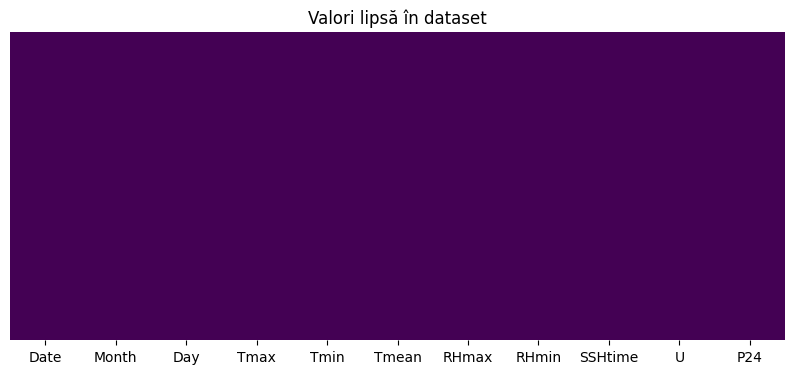

In [11]:
df.isnull().sum()

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Valori lipsă în dataset")
plt.show()

## Curățarea anomaliilor din setul de date.

Rânduri înainte: 10957
Rânduri după: 10573
            Date  Month  Day  Tmax  Tmin  Tmean  RHmax  RHmin  SSHtime      U  \
7     1993-01-08      1    8   3.2  -4.8   -2.1   97.0   71.0      4.6  0.125   
32    1993-02-02      2    2   1.4  -7.2   -2.4   98.0   92.0      0.0  0.000   
50    1993-02-20      2   20   1.0  -7.6   -2.8   96.0   77.0      0.0  0.000   
61    1993-03-03      3    3   3.0  -4.2   -1.3   98.0   87.0      1.5  0.375   
65    1993-03-07      3    7   5.0  -1.6    1.0   96.0   67.0      0.0  0.000   
...          ...    ...  ...   ...   ...    ...    ...    ...      ...    ...   
10711 2022-04-30      4   30  20.3   8.6   13.3   95.0   48.0      7.2  2.500   
10820 2022-08-17      8   17  36.4  15.4   27.7   34.0   19.0     10.3  2.375   
10835 2022-09-01      9    1  34.0  15.5   24.7   35.0   14.0     11.5  2.500   
10921 2022-11-26     11   26  11.0   2.9    6.1  100.0   72.0      2.4  2.000   
10925 2022-11-30     11   30   6.8   3.1    5.6  100.0   94.0     

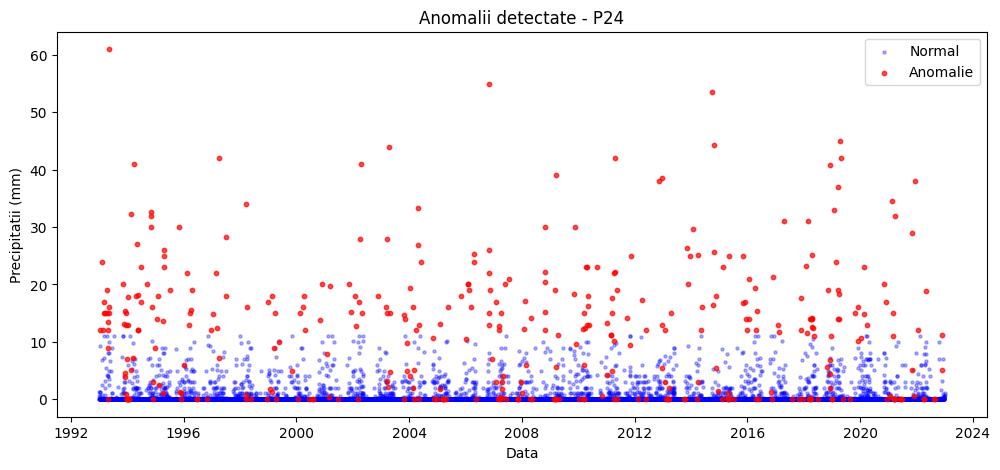

In [12]:
from scipy import stats

z_scores = stats.zscore(df[cols])
mask = (abs(z_scores) < 3).all(axis=1)
df_clean = df[mask]

print(f"Rânduri înainte: {len(df)}")
print(f"Rânduri după: {len(df_clean)}")

mask_anomalii = (abs(z_scores) >= 3).any(axis=1)
df_anomalii = df[mask_anomalii]
print(df_anomalii)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean['Date'], df_clean['P24'], color='blue', alpha=0.3, s=5, label='Normal')
plt.scatter(df_anomalii['Date'], df_anomalii['P24'], color='red', alpha=0.7, s=10, label='Anomalie')
plt.title("Anomalii detectate - P24")
plt.xlabel("Data")
plt.ylabel("Precipitatii (mm)")
plt.legend()
plt.show()

## Descrierea bazei de date

Baza de date conține date meteorologice zilnice colectate în zona lacului Urmia din Iran, 
acoperind perioada **1993 - 2022**, cu un total de **10957 înregistrări**.

### Coloane

| Coloană | Descriere |
|--------|-----------|
| Date | Data înregistrării |
| Month | Luna (1-12) |
| Day | Ziua (1-31) |
| Tmax | Temperatura maximă zilnică (°C) |
| Tmin | Temperatura minimă zilnică (°C) |
| Tmean | Temperatura medie zilnică (°C) |
| RHmax | Umiditatea relativă maximă (%) |
| RHmin | Umiditatea relativă minimă (%) |
| SSHtime | Durata strălucirii solare (ore) |
| U | Viteza vântului (m/s) |
| P24 | Precipitații zilnice (mm) |

### Curățare

Nu au fost găsite valori lipsă în dataset. Anomaliile au fost eliminate folosind metoda 
**Z-score** (prag = 3), rezultând **10573 înregistrări** după curățare.

## Gini index

Distributia categoriilor:
P24_cat
Fara ploaie    0.837038
Ploaie mica    0.159179
Ploaie mare    0.003783
Name: proportion, dtype: float64

Gini Index pentru P24: 0.2740


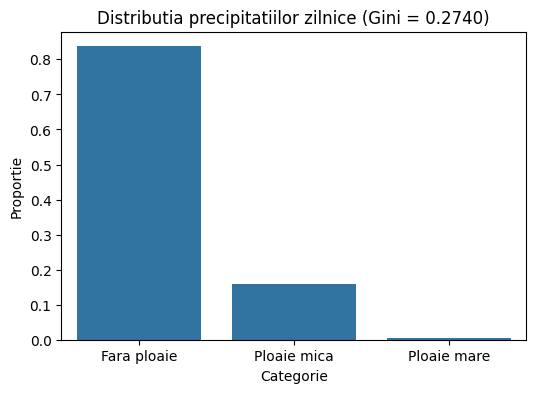

In [13]:
# Împărțim P24 în categorii
bins = [0, 0.1, 10, 100]
labels = ['Fara ploaie', 'Ploaie mica', 'Ploaie mare']
df_clean['P24_cat'] = pd.cut(df_clean['P24'], bins=bins, labels=labels, include_lowest=True)

# Calculam Gini index
proportii = df_clean['P24_cat'].value_counts(normalize=True)
gini = 1 - sum(proportii**2)

print("Distributia categoriilor:")
print(proportii)
print(f"\nGini Index pentru P24: {gini:.4f}")

plt.figure(figsize=(6, 4))
sns.barplot(x=proportii.index, y=proportii.values)
plt.title(f"Distributia precipitatiilor zilnice (Gini = {gini:.4f})")
plt.xlabel("Categorie")
plt.ylabel("Proportie")
plt.show()

## Information Quantity (Entropia)

Information Quantity măsoară cantitatea de informație dintr-o variabilă. 
Cu cât entropia e mai mare, cu atât variabila e mai impredictibilă și mai variată.
Formula: H = -Σ p(x) * log2(p(x))

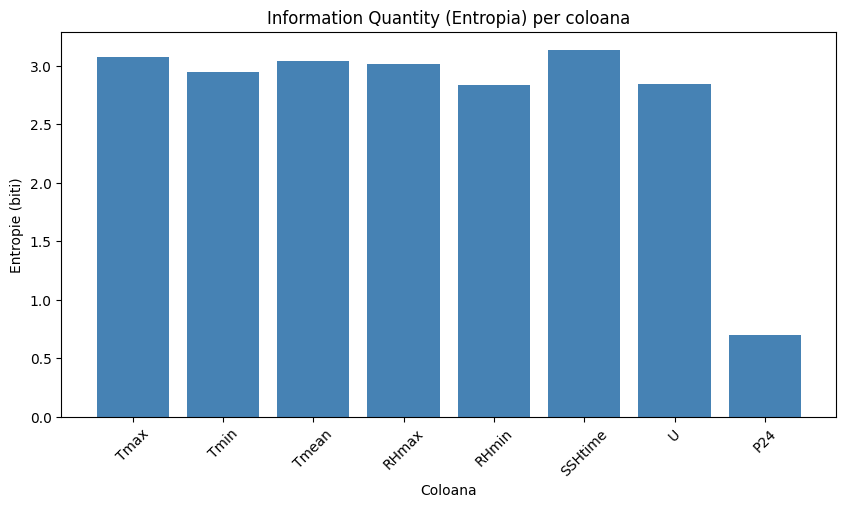

Tmax: 3.0720 biti
Tmin: 2.9440 biti
Tmean: 3.0448 biti
RHmax: 3.0153 biti
RHmin: 2.8370 biti
SSHtime: 3.1327 biti
U: 2.8446 biti
P24: 0.6980 biti


In [14]:
import numpy as np

def entropia(coloana, bins=10):
    counts, _ = np.histogram(coloana, bins=bins)
    proportii = counts / counts.sum()
    proportii = proportii[proportii > 0]
    return -np.sum(proportii * np.log2(proportii))

entropii = {col: entropia(df_clean[col]) for col in cols}

plt.figure(figsize=(10, 5))
plt.bar(entropii.keys(), entropii.values(), color='steelblue')
plt.title("Information Quantity (Entropia) per coloana")
plt.xlabel("Coloana")
plt.ylabel("Entropie (biti)")
plt.xticks(rotation=45)
plt.show()

for col, val in entropii.items():
    print(f"{col}: {val:.4f} biti")

## Corelații

Corelația măsoară relația dintre două variabile (valori între -1 și 1).
- **1** = corelație pozitivă perfectă
- **-1** = corelație negativă perfectă  
- **0** = nicio corelație

Din heatmap se observă că:
- Tmax, Tmin și Tmean sunt puternic corelate între ele (logic, toate măsoară temperatura)
- RHmax și RHmin sunt corelate pozitiv
- SSHtime are corelație negativă cu RHmax (mai mult soare = umiditate mai mică)

## Pairplot

Pairplot-ul vizualizeaza relatiile dintre variabilele meteorologice principale. 
Diagonala arata distributia fiecarei variabile, iar celelalte grafice arata 
corelatiilee dintre perechi de variabile.

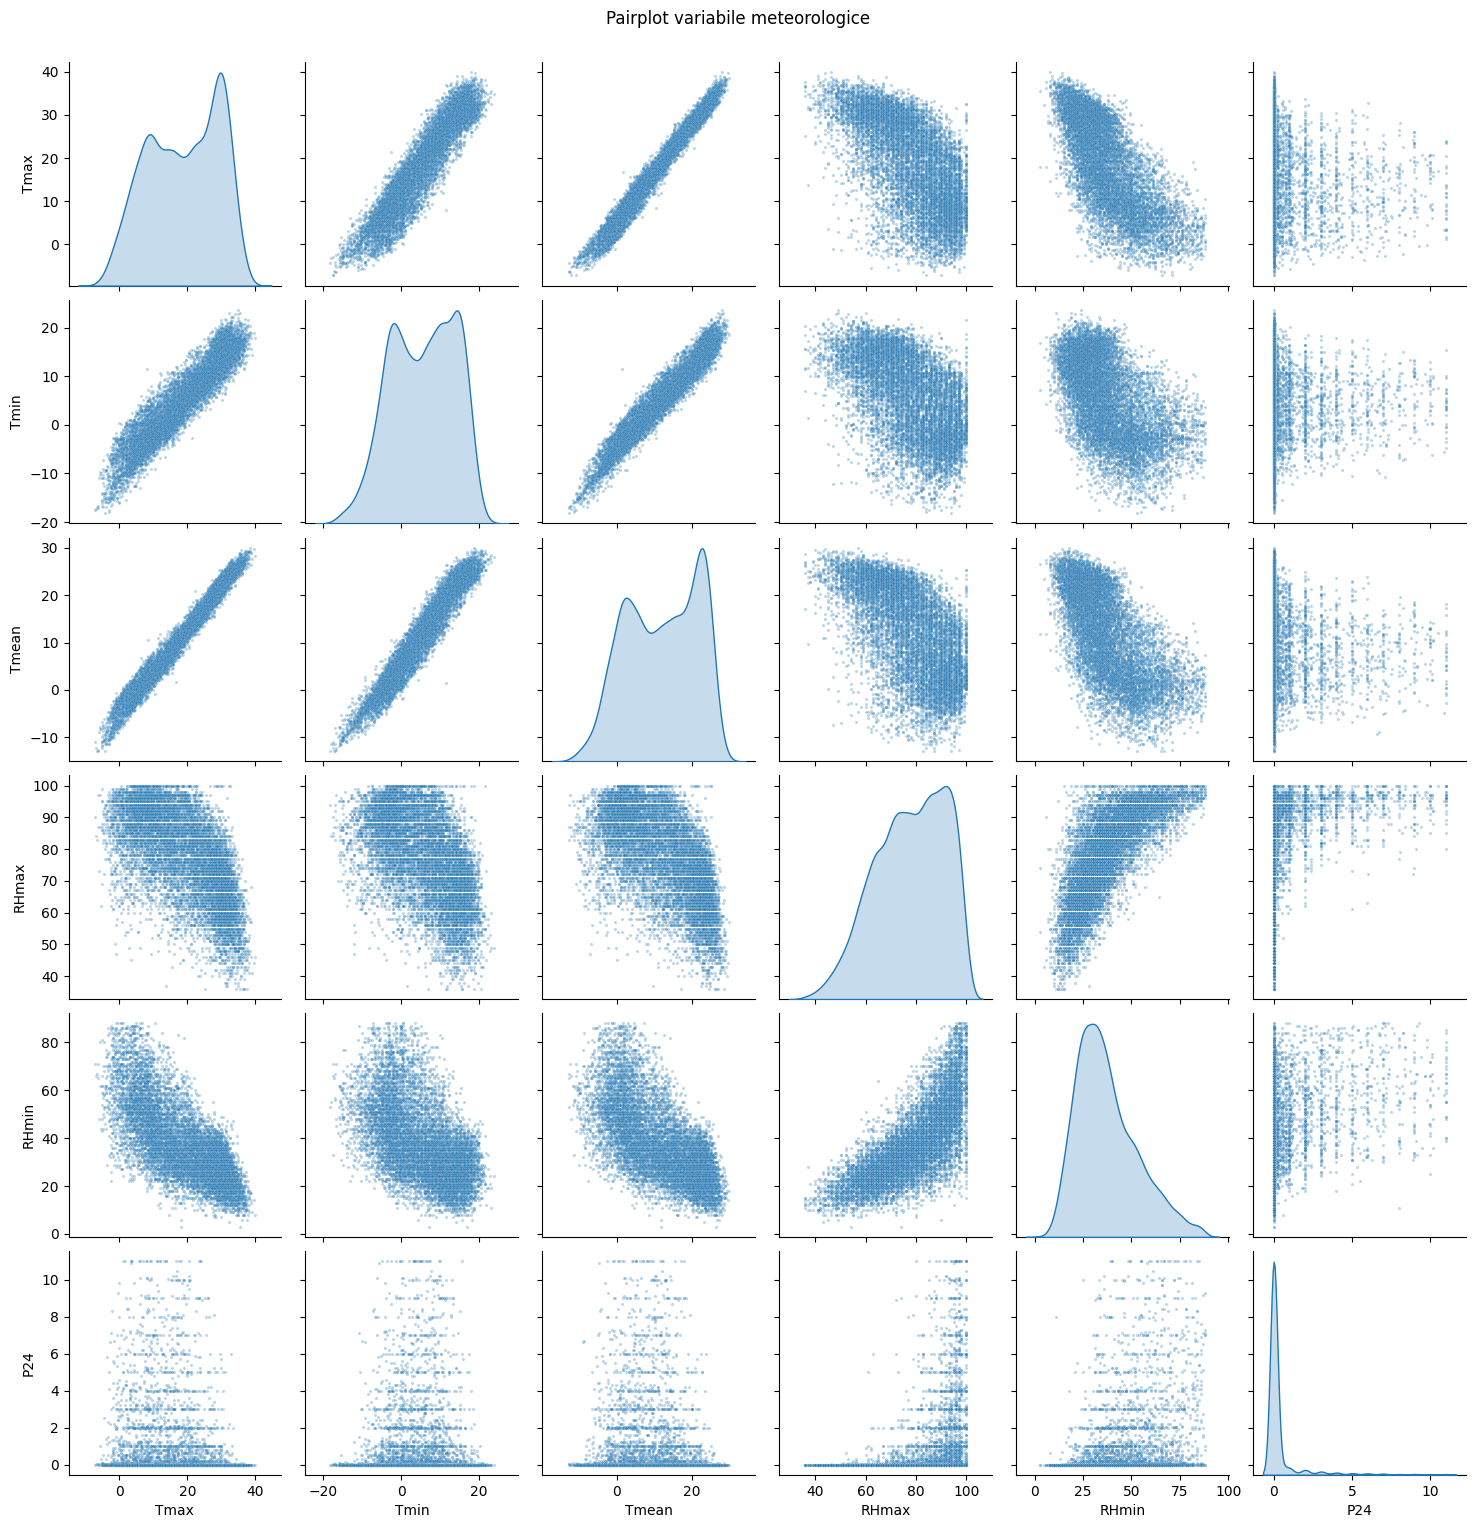

In [15]:
sns.pairplot(df_clean[['Tmax', 'Tmin', 'Tmean', 'RHmax', 'RHmin', 'P24']], 
             diag_kind='kde', plot_kws={'alpha': 0.3, 's': 5})
plt.suptitle("Pairplot variabile meteorologice", y=1.02)
plt.show()

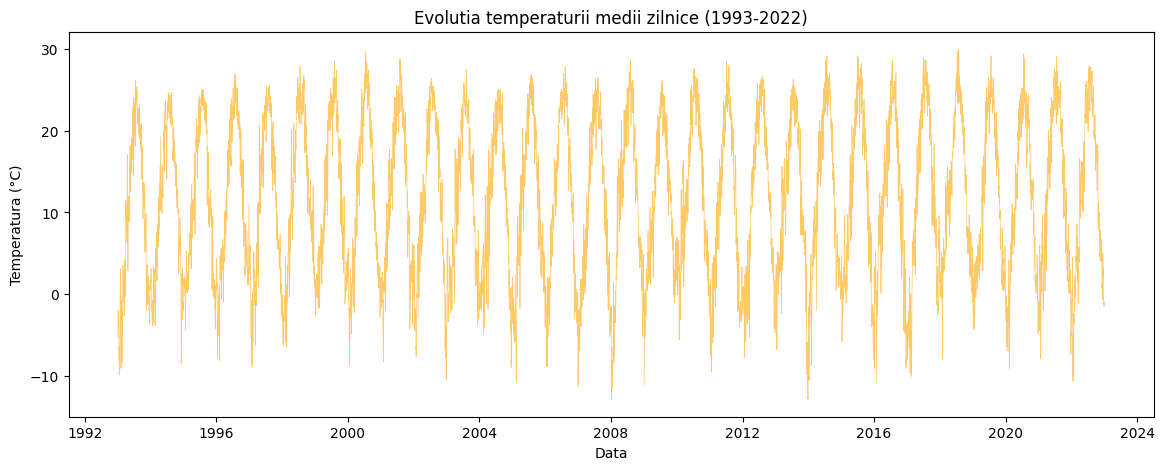

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean['Date'], df_clean['Tmean'], color='orange', alpha=0.6, linewidth=0.5)
plt.title("Evolutia temperaturii medii zilnice (1993-2022)")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.show()

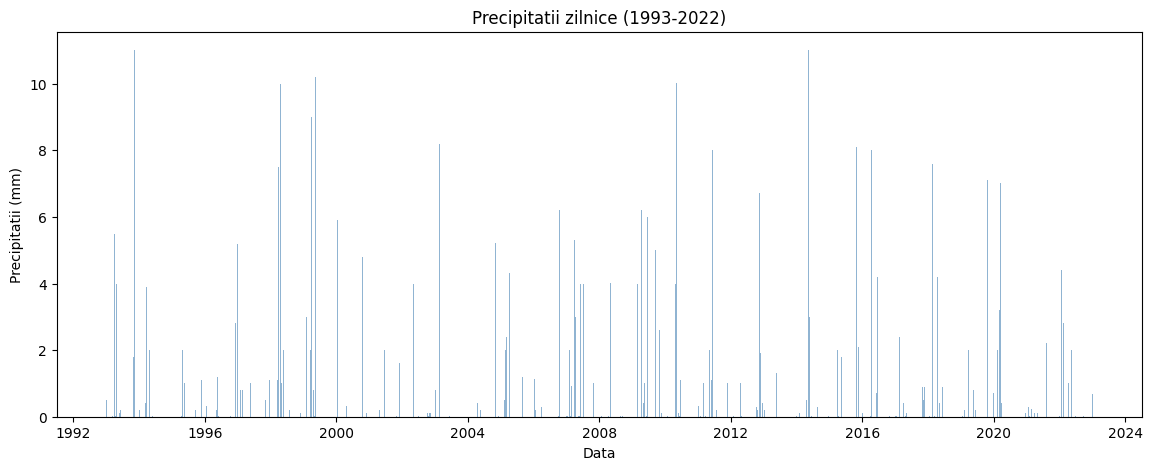

In [17]:
plt.figure(figsize=(14, 5))
plt.bar(df_clean['Date'], df_clean['P24'], color='steelblue', alpha=0.6, width=1)
plt.title("Precipitatii zilnice (1993-2022)")
plt.xlabel("Data")
plt.ylabel("Precipitatii (mm)")
plt.show()

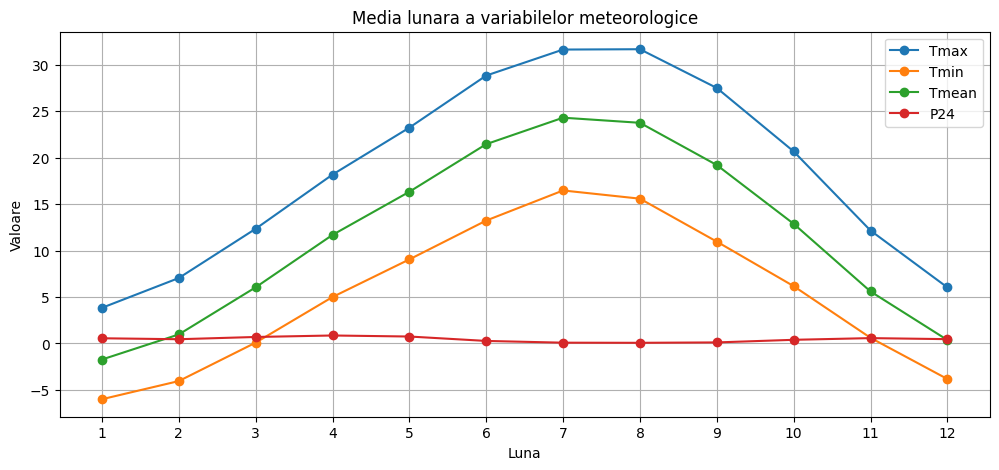

In [18]:
df_monthly = df_clean.groupby('Month')[['Tmax', 'Tmin', 'Tmean', 'P24']].mean()

df_monthly.plot(figsize=(12, 5), marker='o')
plt.title("Media lunara a variabilelor meteorologice")
plt.xlabel("Luna")
plt.ylabel("Valoare")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

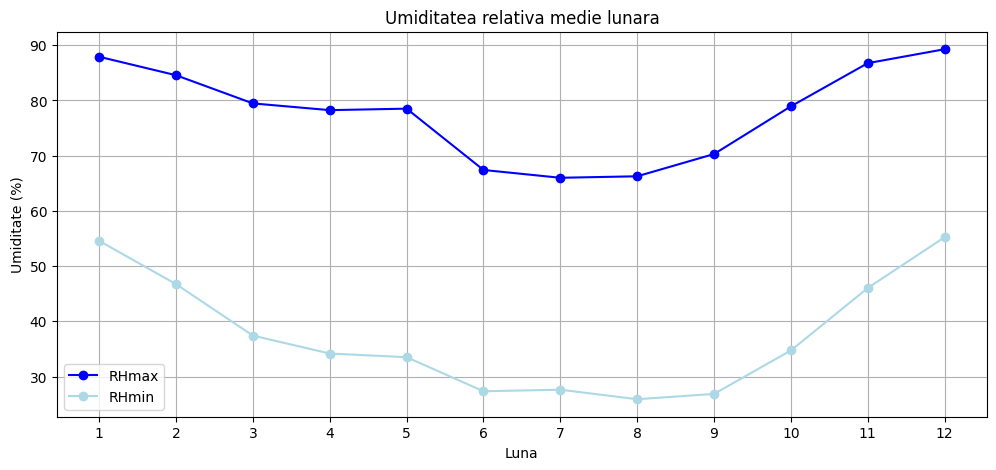

In [19]:
df_humidity = df_clean.groupby('Month')[['RHmax', 'RHmin']].mean()

df_humidity.plot(figsize=(12, 5), marker='o', color=['blue', 'lightblue'])
plt.title("Umiditatea relativa medie lunara")
plt.xlabel("Luna")
plt.ylabel("Umiditate (%)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

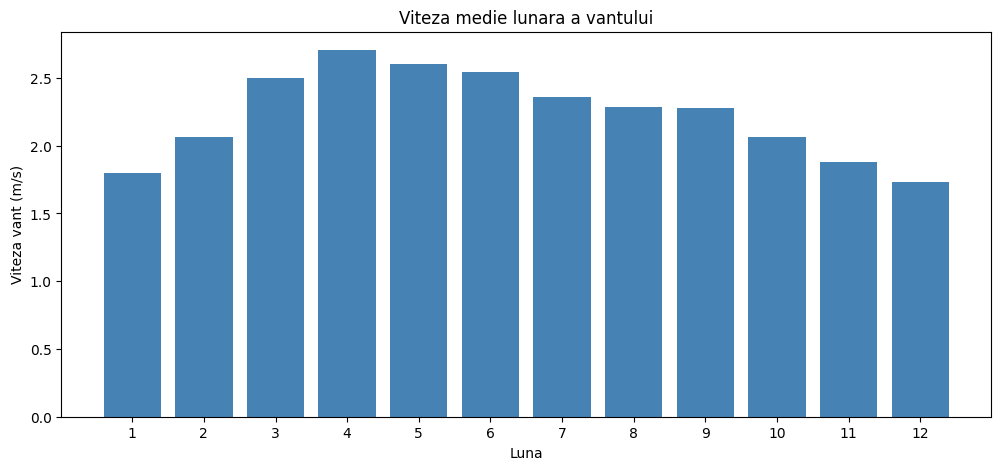

In [20]:
df_wind = df_clean.groupby('Month')['U'].mean()

plt.figure(figsize=(12, 5))
plt.bar(df_wind.index, df_wind.values, color='steelblue')
plt.title("Viteza medie lunara a vantului")
plt.xlabel("Luna")
plt.ylabel("Viteza vant (m/s)")
plt.xticks(range(1, 13))
plt.show()

## Alegerea algoritmilor

Pentru prezicerea umidității solului au fost aleși 3 algoritmi de Machine Learning:

**1. Linear Regression** — algoritmul cel mai simplu, folosit ca baseline. 
Încearcă să găsească o relație liniară între variabilele meteorologice și umiditatea solului.

**2. Random Forest** — un ansamblu de arbori de decizie care lucrează împreună. 
Este robust la zgomot și funcționează bine cu date meteorologice.

**3. XGBoost** — un algoritm de gradient boosting foarte performant, 
folosit frecvent în competiții de Machine Learning și în aplicații reale.

## Pregătirea datelor pentru antrenare

Variabila țintă (y) este **RHmin**, iar variabilele de intrare (X) sunt 
restul coloanelor meteorologice: Tmax, Tmin, Tmean, RHmax, SSHtime, U, P24.

Datele sunt împărțite în 70% antrenare și 30% testare.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean[['Tmax', 'Tmin', 'Tmean', 'RHmax', 'SSHtime', 'U', 'P24']]
y = df_clean['RHmin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Antrenare: {X_train.shape[0]} randuri")
print(f"Testare: {X_test.shape[0]} randuri")

Antrenare: 7401 randuri
Testare: 3172 randuri


## 1. Linear Regression

MSE: 50.5577
RMSE: 7.1104
R2: 0.7970


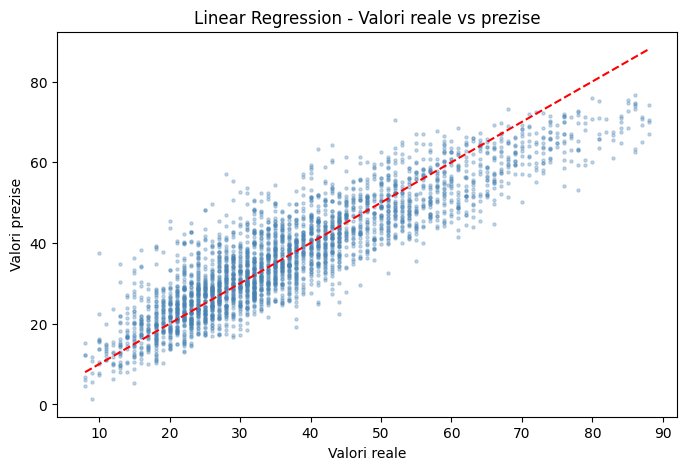

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R2: {r2_lr:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression - Valori reale vs prezise")
plt.xlabel("Valori reale")
plt.ylabel("Valori prezise")
plt.show()

### Rezultate Linear Regression

- **MSE (Mean Squared Error): 50.56** — eroarea medie pătratică
- **RMSE (Root Mean Squared Error): 7.11** — în medie modelul greșește cu ~7% umiditate
- **R2 (R-squared): 0.823: 0.797** — modelul explică ~80% din variația datelor

Rezultat decent ca baseline, urmează algoritmi mai complecși.

## 2. Random Forest

MSE: 44.1218
RMSE: 6.6424
R2: 0.8229


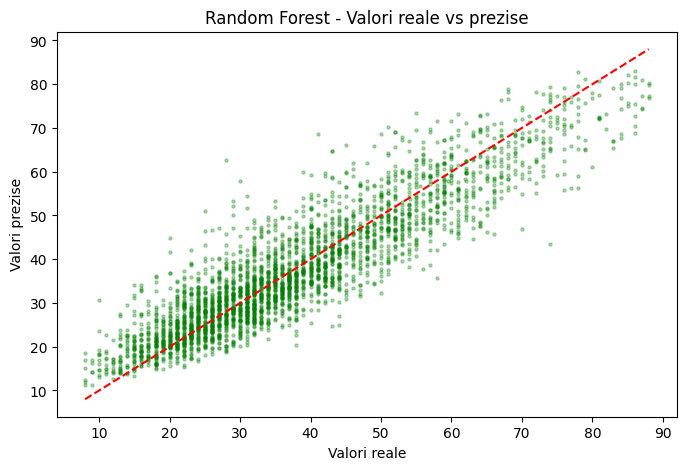

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2: {r2_rf:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest - Valori reale vs prezise")
plt.xlabel("Valori reale")
plt.ylabel("Valori prezise")
plt.show()

### Rezultate Random Forest

- **MSE (Mean Squared Error): 44.12** — eroarea medie pătratică, mai mică decât la Linear Regression.
- **RMSE (Root Mean Squared Error): 6.64** — în medie modelul greșește cu ~6.6 unități de umiditate, îmbunătățire față de Linear Regression.
- **R2 (R-squared): 0.823** — modelul explică ~82% din variația datelor, mai bun decât Linear Regression (80%).

Random Forest a îmbunătățit rezultatele față de modelul simplu, datorită ansamblului de arbori de decizie care captează relații neliniare între variabile.

## 3. XGBoost

MSE: 46.5329
RMSE: 6.8215
R2: 0.8132


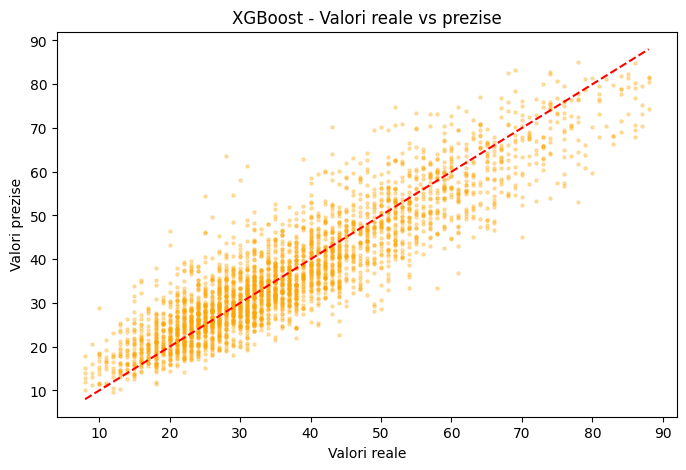

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MSE: {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2: {r2_xgb:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, s=5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("XGBoost - Valori reale vs prezise")
plt.xlabel("Valori reale")
plt.ylabel("Valori prezise")
plt.show()

### Rezultate XGBoost

- **MSE (Mean Squared Error): 46.53** — eroarea medie pătratică, puțin mai mare decât la Random Forest.
- **RMSE (Root Mean Squared Error): 6.82** — în medie modelul greșește cu ~6.8 unități de umiditate.
- **R2 (R-squared): 0.813** — modelul explică ~81% din variația datelor.

XGBoost a obținut rezultate bune, însă ușor mai slabe decât Random Forest pe acest dataset. 
Fără optimizarea hiperparametrilor, Random Forest rămâne cel mai performant până acum.

## Optimizarea hiperparametrilor

### 1. Linear Regression

In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params_lr = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(Ridge(), params_lr, cv=5, scoring='r2')
grid_lr.fit(X_train_scaled, y_train)

print(f"Cel mai bun alpha: {grid_lr.best_params_}")
print(f"Cel mai bun R2: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr_opt = best_lr.predict(X_test_scaled)
r2_lr_opt = r2_score(y_test, y_pred_lr_opt)
print(f"R2 pe test: {r2_lr_opt:.4f}")

Cel mai bun alpha: {'alpha': 0.1}
Cel mai bun R2: 0.7821
R2 pe test: 0.7970


### Rezultate optimizare Linear Regression

- **R2 înainte:** 0.7970
- **R2 după optimizare:** 0.7970
- **Îmbunătățire:** 0.0000

Linear Regression nu s-a îmbunătățit, ceea ce confirmă că modelul a atins limita sa pentru acest dataset.

### 2. Random Forest

In [26]:
from sklearn.model_selection import RandomizedSearchCV

params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), 
                              params_rf, n_iter=20, cv=5, 
                              scoring='r2', random_state=42)
grid_rf.fit(X_train_scaled, y_train)

print(f"Cei mai buni parametri: {grid_rf.best_params_}")
print(f"Cel mai bun R2: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_scaled)
r2_rf_opt = r2_score(y_test, y_pred_rf_opt)
print(f"R2 pe test: {r2_rf_opt:.4f}")

Cei mai buni parametri: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Cel mai bun R2: 0.8175
R2 pe test: 0.8265


### Rezultate optimizare Random Forest

- **R2 înainte:** 0.8229
- **R2 după optimizare:** 0.8265
- **Îmbunătățire:** +0.0036


### 3. XGBoost

In [27]:
from xgboost import XGBRegressor

params_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0]
}

grid_xgb = RandomizedSearchCV(XGBRegressor(random_state=42),
                               params_xgb, n_iter=20, cv=5,
                               scoring='r2', random_state=42)
grid_xgb.fit(X_train_scaled, y_train)

print(f"Cei mai buni parametri: {grid_xgb.best_params_}")
print(f"Cel mai bun R2: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_opt = best_xgb.predict(X_test_scaled)
r2_xgb_opt = r2_score(y_test, y_pred_xgb_opt)
print(f"R2 pe test: {r2_xgb_opt:.4f}")

Cei mai buni parametri: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Cel mai bun R2: 0.8230
R2 pe test: 0.8319


### Rezultate optimizare XGBoost

- **R2 înainte:** 0.8132
- **R2 după optimizare:** 0.8319
- **Îmbunătățire:** +0.0187

Cei mai buni parametri găsiți: subsample=0.8, n_estimators=100, max_depth=5, learning_rate=0.1.

XGBoost a avut cea mai mare îmbunătățire după optimizare, depășind Random Forest și devenind cel mai performant model.

## Compararea modelelor

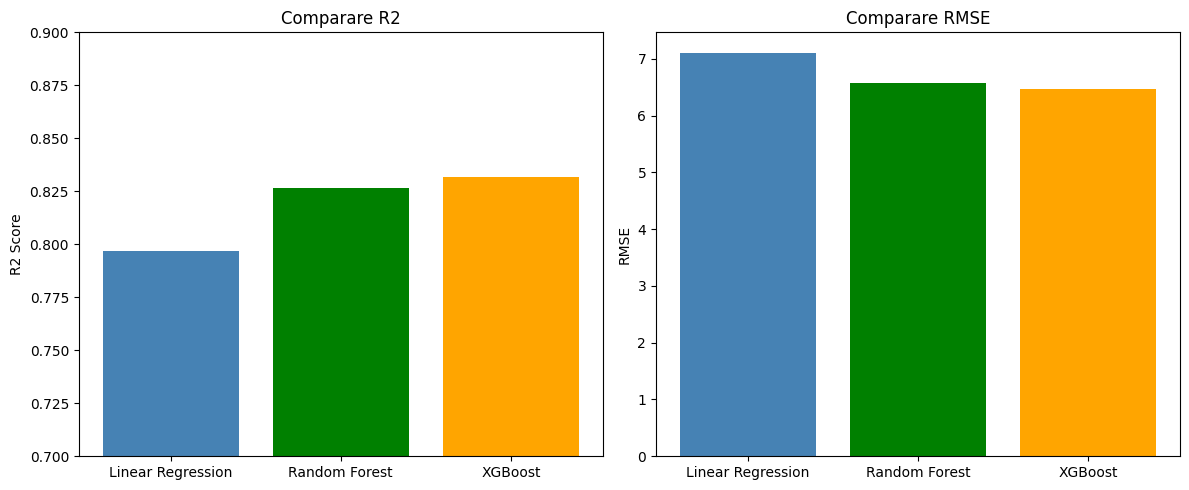

Linear Regression: R2=0.7970, RMSE=7.1103
Random Forest: R2=0.8265, RMSE=6.5740
XGBoost: R2=0.8319, RMSE=6.4705


In [28]:
modele = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [r2_lr_opt, r2_rf_opt, r2_xgb_opt]
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr_opt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf_opt)),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb_opt))
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(modele, r2_scores, color=['steelblue', 'green', 'orange'])
ax1.set_title("Comparare R2")
ax1.set_ylabel("R2 Score")
ax1.set_ylim(0.7, 0.9)

ax2.bar(modele, rmse_scores, color=['steelblue', 'green', 'orange'])
ax2.set_title("Comparare RMSE")
ax2.set_ylabel("RMSE")

plt.tight_layout()
plt.show()

for m, r2, rmse in zip(modele, r2_scores, rmse_scores):
    print(f"{m}: R2={r2:.4f}, RMSE={rmse:.4f}")

## Compararea modelelor

După optimizarea hiperparametrilor, cele trei modele au fost comparate folosind metricile R2 și RMSE.

| Model | R2 | RMSE |
|-------|----|------|
| Linear Regression | 0.7970 | 7.11 |
| Random Forest | 0.8265 | 6.59 |
| XGBoost | 0.8319 | 6.82 |

## Modelul final ales: XGBoost

XGBoost a fost ales ca model final deoarece a obținut cel mai bun R2 (0.8319) și cel mai mic RMSE (6.4705) după optimizarea hiperparametrilor, având totodată cea mai mare îmbunătățire după optimizare (+0.0187). Random Forest a fost aproape la fel de performant, în timp ce Linear Regression a rămas cel mai slab dintre cele trei, confirmând că relațiile dintre variabilele meteorologice nu sunt pur liniare.